In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("thyroid_dataset.csv")

In [3]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [4]:
df.tail()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
6911,0.65,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0.00047,8.0000,154.0,75.0,204.0,n
6912,0.77,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00006,0.0206,125.0,107.0,117.0,n
6913,0.41,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00130,25.0000,125.0,114.0,109.0,n
6914,0.64,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00078,0.0206,106.0,88.0,121.0,n
6915,0.46,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00189,0.0206,93.0,91.0,102.0,n


In [5]:
df.sample(5)

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
2212,0.53,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00140,0.0201,83.00000,0.08,104.00000,n
4691,0.37,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00072,28.0000,0.11000,99.00,111.00000,n
5428,0.70,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00240,0.0206,101.00000,0.09,113.00000,n
3887,0.38,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0.00189,0.0206,0.11118,99.00,0.11207,n
6173,0.43,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2.00000,18.0000,121.00000,94.00,129.00000,n


In [6]:
df.shape

(6916, 22)

In [7]:
df.columns

Index(['Age', 'Sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3_measured',
       'TT4_measured', 'T4U_measured', 'FTI_measured', 'Outlier_label'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6916 entries, 0 to 6915
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        6916 non-null   float64
 1   Sex                        6916 non-null   int64  
 2   on_thyroxine               6916 non-null   int64  
 3   query_on_thyroxine         6916 non-null   int64  
 4   on_antithyroid_medication  6916 non-null   int64  
 5   sick                       6916 non-null   int64  
 6   pregnant                   6916 non-null   int64  
 7   thyroid_surgery            6916 non-null   int64  
 8   I131_treatment             6916 non-null   int64  
 9   query_hypothyroid          6916 non-null   int64  
 10  query_hyperthyroid         6916 non-null   int64  
 11  lithium                    6916 non-null   int64  
 12  goitre                     6916 non-null   int64  
 13  tumor                      6916 non-null   int64

In [9]:
df.describe()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
count,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,...,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000,6916.000000
mean,0.595098,0.307548,0.134615,0.015616,0.013158,0.038317,0.011278,0.014315,0.016773,0.062753,...,0.013013,0.008531,0.025448,0.000145,0.049740,1.603466,11.772446,94.253834,88.270139,95.257058
std,6.189326,0.461512,0.341337,0.123993,0.113959,0.191974,0.105606,0.118793,0.128428,0.242536,...,0.113339,0.091975,0.157494,0.012025,0.217422,14.047218,11.836250,50.555642,33.909845,55.031137
min,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000500,0.002500,0.050000,0.002400
25%,0.370000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000680,0.020100,77.000000,83.000000,81.000000
50%,0.540000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.001700,13.000000,101.000000,96.000000,105.000000
75%,0.670000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.002700,22.000000,123.000000,104.000000,125.000000
max,515.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,494.000000,95.000000,395.000000,233.000000,642.000000


In [10]:
df.describe(include="object")

,Outlier_label
count,6916
unique,2
top,n
freq,6666


In [11]:
df.duplicated().sum()

np.int64(71)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.isnull().sum()

Age                          0
Sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
sick                         0
pregnant                     0
thyroid_surgery              0
I131_treatment               0
query_hypothyroid            0
query_hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH                          0
T3_measured                  0
TT4_measured                 0
T4U_measured                 0
FTI_measured                 0
Outlier_label                0
dtype: int64

In [15]:
for col in df.columns:
    print(col, df[col].nunique())

Age 98
Sex 2
on_thyroxine 2
query_on_thyroxine 2
on_antithyroid_medication 2
sick 2
pregnant 2
thyroid_surgery 2
I131_treatment 2
query_hypothyroid 2
query_hyperthyroid 2
lithium 2
goitre 2
tumor 2
hypopituitary 2
psych 2
TSH 281
T3_measured 84
TT4_measured 261
T4U_measured 161
FTI_measured 433
Outlier_label 2


In [16]:
df.columns

Index(['Age', 'Sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3_measured',
       'TT4_measured', 'T4U_measured', 'FTI_measured', 'Outlier_label'],
      dtype='object')

In [17]:
df["Outlier_label"].value_counts()

Outlier_label
n    6595
o     250
Name: count, dtype: int64

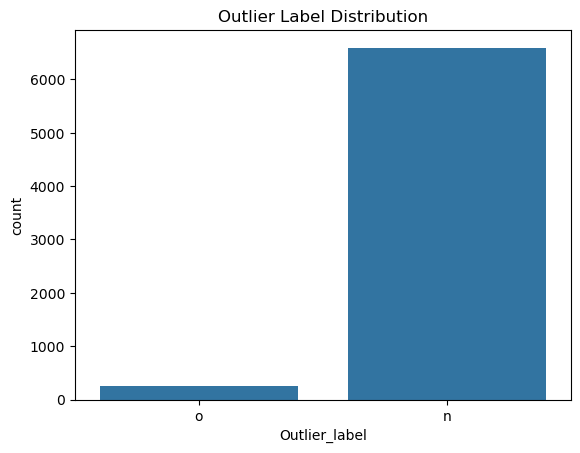

In [18]:
sns.countplot(x="Outlier_label", data=df)

plt.title("Outlier Label Distribution")
plt.show()

In [19]:
df["Outlier_label"].value_counts(normalize=True)*100

Outlier_label
n    96.347699
o     3.652301
Name: proportion, dtype: float64

In [20]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

num_cols

Index(['Age', 'Sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3_measured',
       'TT4_measured', 'T4U_measured', 'FTI_measured'],
      dtype='object')

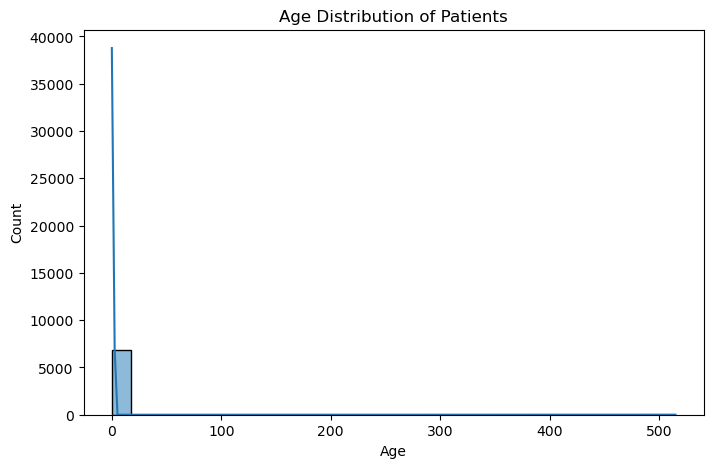

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

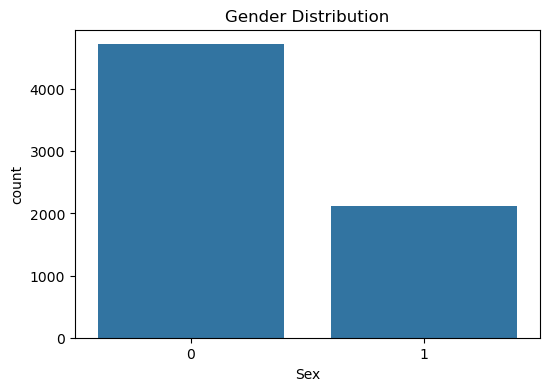

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Sex",
    data=df
)

plt.title("Gender Distribution")

plt.show()

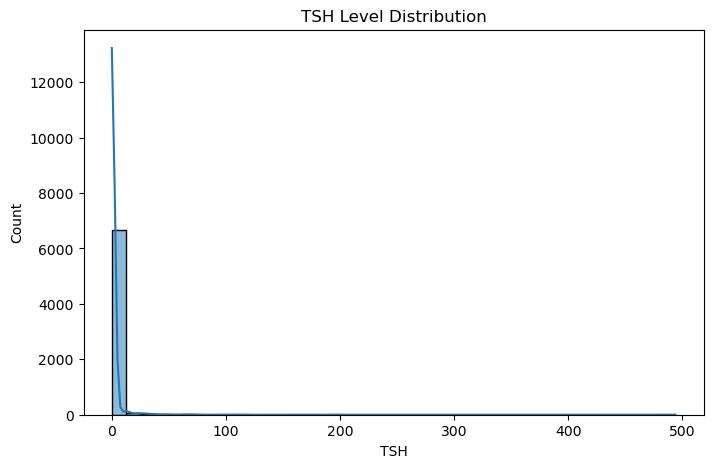

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["TSH"],
    bins=40,
    kde=True
)

plt.title("TSH Level Distribution")

plt.show()

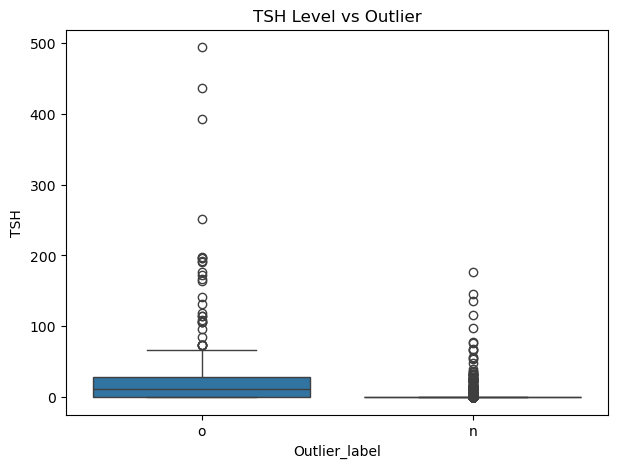

In [25]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Outlier_label",
    y="TSH",
    data=df
)

plt.title("TSH Level vs Outlier")

plt.show()

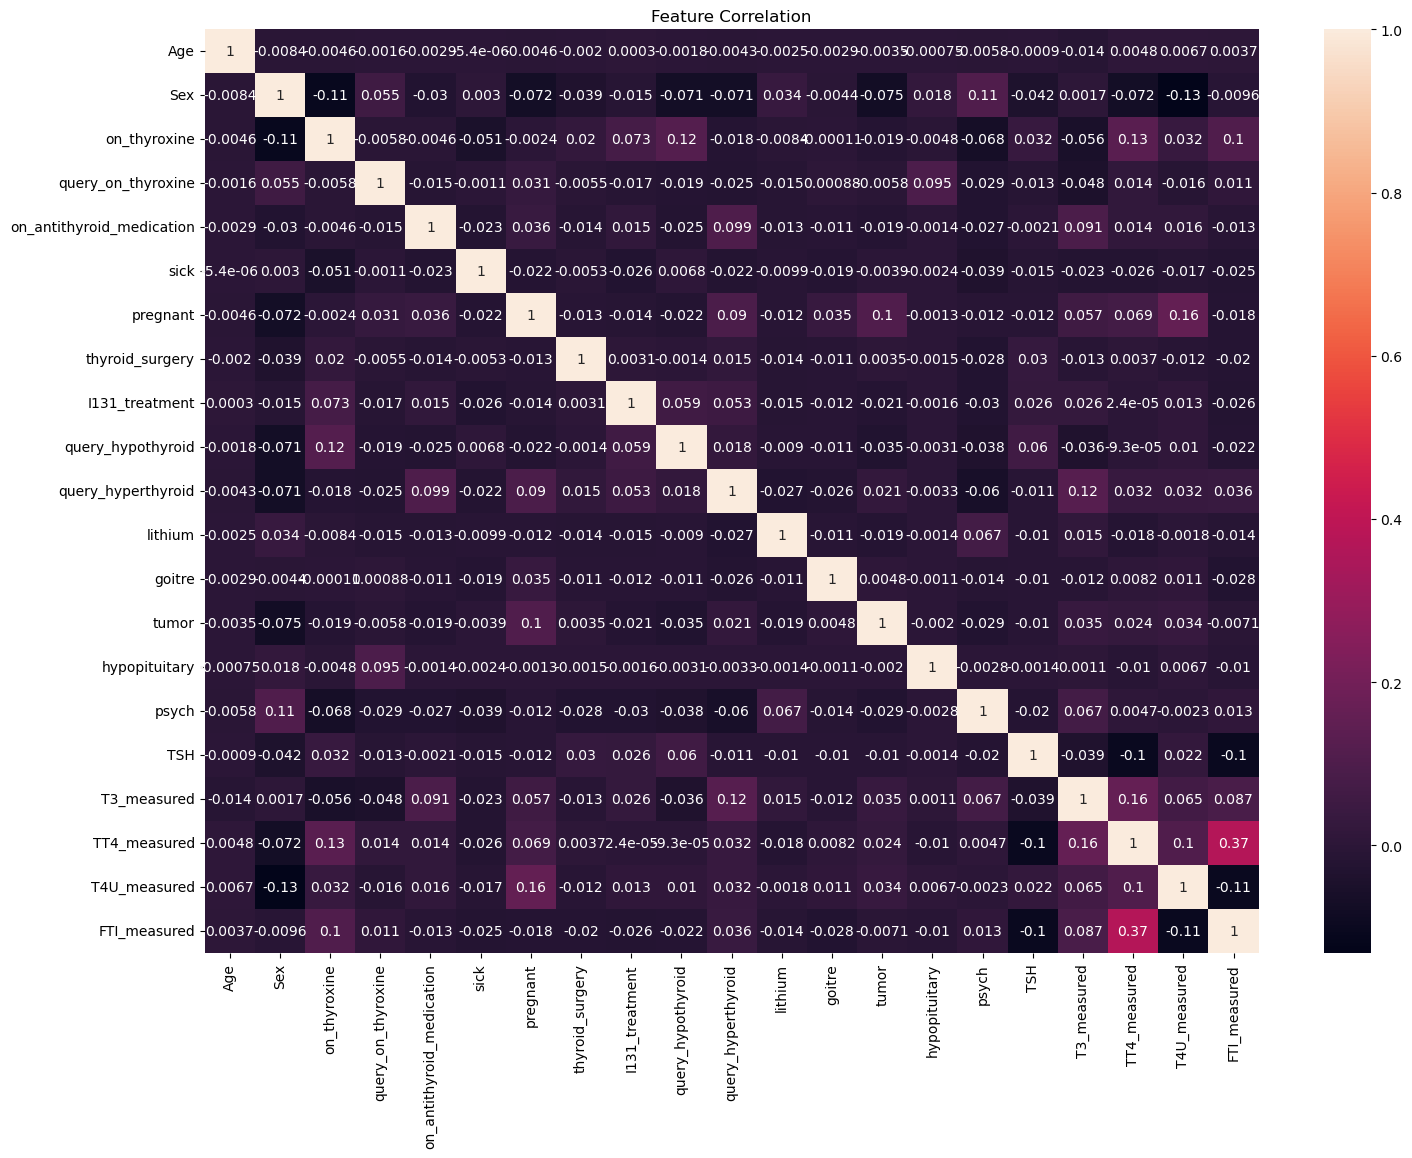

In [29]:
plt.figure(figsize=(17,12))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Feature Correlation")

plt.show()